In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import ParameterGrid
from pathlib import Path

import joblib
import logging
from tqdm.auto import tqdm

import sys
sys.path.append('../')
import src.fda.kde.estimators           as kde
import src.fda.plots                    as fplt
import src.fda.utils                    as fdaUtils
import src.fda.transformations.lqdt     as lqdt
import src.forecasting.pipelines        as fc
import src.forecasting.cross_validation as crossVal
import src.forecasting.accuracy         as acc

from datetime import datetime

In [2]:
EXECUTION_DATE : str = datetime.now().strftime('%Y%m%d')
LOG_PATH       : str = f'../logs/cross_validation_{EXECUTION_DATE}.log'
FILES_PATH     : str = f'../data/processed/cv/{EXECUTION_DATE}/'

Path(FILES_PATH).mkdir(parents=True, exist_ok=True)

In [3]:
data_path = "../data/processed/"
returns_path = ''.join([data_path, 'ibovespa_treated.xlsx'])
df_returns = pd.read_excel(returns_path, index_col="time")
df_returns.head()

,2024-12-02,2024-12-03,2024-12-04,2024-12-05,2024-12-06,2024-12-09,2024-12-10,2024-12-11,2024-12-12,2024-12-13,...,2025-11-14,2025-11-17,2025-11-18,2025-11-19,2025-11-21,2025-11-24,2025-11-25,2025-11-26,2025-11-27,2025-11-28
time,,,,,,,,,,,,,,,,,,,,,
10:05:00,-0.002271,0.003372,0.001716,0.005538,0.000069,0.006429,0.002343,0.001918,-0.007582,-0.000413,...,-0.001522,0.000739,-0.000613,0.000306,-0.002021,-0.000810,0.001557,-0.001565,-0.000193,0.002906
10:10:00,-0.000582,0.002832,-0.000502,0.000739,0.000261,0.001891,0.000775,-0.001172,0.000216,-0.000432,...,0.000360,-0.000105,-0.000159,-0.000362,0.000092,0.001131,0.001170,0.000202,0.000556,0.000475
10:15:00,-0.001997,0.001091,0.000111,-0.000192,0.000407,-0.001392,-0.000477,-0.001526,0.000198,-0.001821,...,0.001121,-0.000284,0.003272,-0.001107,-0.001012,-0.000174,0.001002,0.001815,-0.000168,0.000973
10:20:00,-0.000037,-0.000505,-0.000327,-0.000580,-0.000436,-0.000405,0.001263,0.000676,-0.002667,0.001033,...,0.000449,0.000335,0.000853,0.000981,-0.000057,-0.000096,0.000832,0.001951,0.001060,-0.001004
10:25:00,0.000364,-0.001532,0.000429,-0.000426,-0.000162,-0.000130,0.000060,0.000818,-0.000970,0.000670,...,-0.000871,-0.000559,0.001030,-0.000749,-0.001194,0.001338,0.000128,0.001279,-0.000162,-0.000651


In [4]:
t_dfs = range(3,6)

# 1. Define the parameter universes for each method
rot_grid = {
    "method": ["rot"],
    "kernel": ["gaussian", "epanechnikov"], #"tophat", "exponential", "linear", "cosine"],
    "sigma_robust": [True, False]
}

lcv_sklearn_grid = {
    "method": ["cross_validate"],
    "kernel": ["gaussian"], #"epanechnikov"], #"tophat", "exponential", "linear", "cosine"],
    "cv": ["LOO"]#[5]
}

adaptive_grid = {
    "method": ["adaptive"], #"dpi"],
    "kernel": ["gaussian", "epanechnikov"],
    # "h": kernel_rules
}

lcv_t_grid = {
    "method": ["cross_validate"],
    "kernel": ["t-student"],
    "df": [df for df in t_dfs],
    "cv": ["LOO"]#, "LOO"] [5]
}

adaptive_grid_t = {
    "method": ["adaptive"], #"dpi"],
    "kernel": ["t-student"],
    "df": [df for df in t_dfs]
}

# 2. Combine grids and build the dictionary
density_param_grid = {}
for grid in [rot_grid, lcv_sklearn_grid, lcv_t_grid, adaptive_grid, adaptive_grid_t]:
    for params in ParameterGrid(grid):
        # Create a unique key based on the parameters
        # e.g., "rot_gaussian_robust_True" or "lcv_t-student_df_3"
        key_parts = [params["kernel"].replace("_","")]
        if "method" in params: key_parts.append(params["method"])
        if "df" in params: key_parts.append(f"df={params['df']}")
        if params.get("sigma_robust"): key_parts.append("robust")
        if params.get("cv") == "LOO": key_parts.append("loo")
        
        # ADD THESE TWO LINES:
        if "alpha" in params: key_parts.append(f"a{params['alpha']}")
        if "h" in params: key_parts.append(f"h{params['h']}") # Distinguish different pilot h values
        
        name = "_".join(key_parts).replace(".", "") # Remove dots for cleaner keys
        density_param_grid[name] = params

print("KDE models:")
for name, params in density_param_grid.items():
    print("\t",name, ":", params)

KDE models:
	 gaussian_rot_robust : {'kernel': 'gaussian', 'method': 'rot', 'sigma_robust': True}
	 gaussian_rot : {'kernel': 'gaussian', 'method': 'rot', 'sigma_robust': False}
	 epanechnikov_rot_robust : {'kernel': 'epanechnikov', 'method': 'rot', 'sigma_robust': True}
	 epanechnikov_rot : {'kernel': 'epanechnikov', 'method': 'rot', 'sigma_robust': False}
	 gaussian_cross_validate_loo : {'cv': 'LOO', 'kernel': 'gaussian', 'method': 'cross_validate'}
	 t-student_cross_validate_df=3_loo : {'cv': 'LOO', 'df': 3, 'kernel': 't-student', 'method': 'cross_validate'}
	 t-student_cross_validate_df=4_loo : {'cv': 'LOO', 'df': 4, 'kernel': 't-student', 'method': 'cross_validate'}
	 t-student_cross_validate_df=5_loo : {'cv': 'LOO', 'df': 5, 'kernel': 't-student', 'method': 'cross_validate'}
	 gaussian_adaptive : {'kernel': 'gaussian', 'method': 'adaptive'}
	 epanechnikov_adaptive : {'kernel': 'epanechnikov', 'method': 'adaptive'}
	 t-student_adaptive_df=3 : {'df': 3, 'kernel': 't-student', 'meth

In [5]:
# Density normalization
# 1. Define your sub-grids to avoid invalid combinations
weigh_grids = [
    {
        'mean_mode': [False, 'expanding'], #'full'],
        'window': [None]
    },
    {
        'mean_mode': ['rolling'],
        'window': [5, 21, 63] # week, month, quarter
    }
]

# 2. Build the dictionary with unique keys
weigh_param_grid = {}
for grid in weigh_grids:
    for params in ParameterGrid(grid):
        # Start the key with the mode
        key_parts = [str(params["mean_mode"])]
        
        # Add the window to the key if it exists (for rolling)
        if params["window"] is not None:
            key_parts.append(f"w{params['window']}")
        
        # Create a clean string key: e.g., "rolling_w5" or "expanding"
        name = "_".join(key_parts)
        weigh_param_grid[name] = params

print("Posprocessing models:")
for name, params in weigh_param_grid.items():
    print("\t",name, ":", params)

Posprocessing models:
	 False : {'mean_mode': False, 'window': None}
	 expanding : {'mean_mode': 'expanding', 'window': None}
	 rolling_w5 : {'mean_mode': 'rolling', 'window': 5}
	 rolling_w21 : {'mean_mode': 'rolling', 'window': 21}
	 rolling_w63 : {'mean_mode': 'rolling', 'window': 63}


In [6]:
theta = []

for kde_name, kde_params in density_param_grid.items():
    for post_name, post_params in weigh_param_grid.items():
        theta.append({
            "kde_name": kde_name,
            **kde_params,
            "postprocess_name": post_name,
            **post_params
        })

print("Total KDE configurations:", len(theta))

Total KDE configurations: 65


In [7]:
kde_databases = joblib.load('../data/processed/kde_databases.jbl')

In [8]:
# Basic dFPC setup
KdFPC_kwargs = {
    "p": 5
}

## dFPC estimation
dimensions_list = range(2,7)
print("Dimensions for dFPC:", len(dimensions_list))

## VAR lags
var_qs = range(1,5)
print("Lags for VAR(q):", len(var_qs))

Dimensions for dFPC: 5
Lags for VAR(q): 4


In [9]:
# 1. Setup Logger
logger = logging.getLogger("Density_Estimation")
logger.setLevel(logging.DEBUG)

# 2. Setup File Handler
file_handler = logging.FileHandler(LOG_PATH)
file_handler.setFormatter(logging.Formatter('%(asctime)s | %(levelname)s | %(message)s'))
logger.addHandler(file_handler)

# 3. CAPTURE WARNINGS: This handles "Forecast with mean" style warnings
logging.captureWarnings(True)

In [10]:
INITIAL_CV_WINDOW = 100
CV_END = 181
df_returns_validation_set = df_returns.iloc[:,:CV_END]

total_params = (len(density_param_grid) * len(weigh_param_grid) * len(dimensions_list) * len(var_qs))
pbar = tqdm(total=total_params, desc="Total CV Progress")
current_count = 0
logger.info("\n\n\n\nInitiating cross validation...")
for name, params in density_param_grid.items():
    print(f"Processing configuration: {name}")
    pbar.set_postfix_str(f"KDE: {name}")
    
    # bandwidths
    df_h = kde.df_bandwidth_selector(df_returns_validation_set, **params)    
    kde_params = {k: v for k, v in params.items() if k in ['kernel', 'df']}
    
    # kdes
    df_support, df_densities = kde.df_to_kde(
        X=df_returns_validation_set, 
        h=df_h, 
        normalize_densities=False,
        **kde_params
    )

    # postprocessing
    for pp_name, pp_params in weigh_param_grid.items():
        database_name = "___".join([name, pp_name])
        print(f"\t\t{database_name}")

        if pp_name == 'False':
            df_densities = df_densities.copy()
        else:
            base_grid = np.linspace(df_support.min().min(), df_support.max().max(), 5001)
            df_densities = kde.weigh_norm_densities(
                                            df_densities=df_densities,
                                            support=base_grid,
                                            **pp_params
                                            )
        
        # dFPC components
        for d in dimensions_list:
            KdFPC_kwargs.update(
                {"dimension": d}
                )

            # VAR(q) lags
            for q in var_qs:
                current_count += 1
                logger.info(
                                    f"Progress: ({current_count}/{total_params}) | "
                                    f"KDE: {name} | PP: {pp_name} | Dim: {d} | VAR(q): {q}"
                                )

                try:
                    cv_mdfpc_measures, mdfpc_cv_curves = crossVal.cv(
                                    df_densities, 
                                    df_support, 
                                    KdFPC_kwargs = KdFPC_kwargs, 
                                    var_lags=q, 
                                    initial_window=INITIAL_CV_WINDOW,
                                    return_curves=True
                                    )

                    cv_dfpc_measures, dfpc_cv_curves = crossVal.cv_dfpc(
                                    df_densities, 
                                    df_support, 
                                    KdFPC_kwargs = KdFPC_kwargs, 
                                    var_lags=q, 
                                    initial_window=INITIAL_CV_WINDOW,
                                    return_curves=True
                                    )

                except Exception as e:
                    # print(f"\t ERROR for d={d} and {params} : {e}")
                    logger.exception(f"\t ERROR for d={d} and {params} : {e}")
                    continue

                pbar.update(1)

                cv_filename = '___'.join([database_name, str(d), str(q)])
                
                model_records = []
                for m in cv_mdfpc_measures:
                    if params["kernel"] == 't_student':
                        kernel_desc = params["kernel"] + "-df-" + str(params["df"])
                    else:
                        kernel_desc = params["kernel"]
                    record = {
                        # Model ID
                        "name": cv_filename,
                       
                        # Model parameters
                        "method": m["method"],
                        "fpc": "mdfpc",
                        "postprocessing_method": pp_name,
                        "kde_params": name,
                        "dFPC_dimensions":   d,
                        "VAR_q": q,

                        # CV
                        "fold": m["fold"]+1,
                        "curves": mdfpc_cv_curves,

                        # ACCURACY
                        'KLD': m["KLD"],
                        'JSD': m["JSD"],
                        'L_1': m["L_1"],
                        'L_2': m["L_2"],
                        'L_INFTY': m["L_INFTY"]
                    }
                    model_records.append(record)

                # model_records_dfpc = []
                for m in cv_dfpc_measures:
                    if params["kernel"] == 't_student':
                        kernel_desc = params["kernel"] + "-df-" + str(params["df"])
                    else:
                        kernel_desc = params["kernel"]
                    record = {
                        # Model ID
                        "name": cv_filename,
                       
                        # Model parameters
                        "method": m["method"],
                        "fpc": "dfpc",
                        "postprocessing_method": pp_name,
                        "kde_params": name,
                        "dFPC_dimensions":   d,
                        "VAR_q": q,

                        # CV
                        "fold": m["fold"]+1,
                        "curves": dfpc_cv_curves,

                        # ACCURACY
                        'KLD': m["KLD"],
                        'JSD': m["JSD"],
                        'L_1': m["L_1"],
                        'L_2': m["L_2"],
                        'L_INFTY': m["L_INFTY"]
                    }
                    model_records.append(record)

                df_mdfpc_records = pd.DataFrame(model_records)
                joblib.dump(df_mdfpc_records, f'../data/processed/cv/{EXECUTION_DATE}/{cv_filename}.jbl', compress=3)


Total CV Progress:   0%|          | 0/1300 [00:00<?, ?it/s]

Processing configuration: gaussian_rot_robust
		gaussian_rot_robust___False
		>>> cv 1/81
		>>> cv 2/81
		>>> cv 3/81
		>>> cv 4/81
		>>> cv 5/81
		>>> cv 6/81
		>>> cv 7/81
		>>> cv 8/81
		>>> cv 9/81
		>>> cv 10/81
		>>> cv 11/81
		>>> cv 12/81
		>>> cv 13/81
		>>> cv 14/81
		>>> cv 15/81
		>>> cv 16/81
		>>> cv 17/81
		>>> cv 18/81
		>>> cv 19/81
		>>> cv 20/81
		>>> cv 21/81
		>>> cv 22/81
		>>> cv 23/81
		>>> cv 24/81
		>>> cv 25/81
		>>> cv 26/81
		>>> cv 27/81
		>>> cv 28/81
		>>> cv 29/81
		>>> cv 30/81
		>>> cv 31/81
		>>> cv 32/81
		>>> cv 33/81
		>>> cv 34/81
		>>> cv 35/81
		>>> cv 36/81
		>>> cv 37/81
		>>> cv 38/81
		>>> cv 39/81
		>>> cv 40/81
		>>> cv 41/81
		>>> cv 42/81
		>>> cv 43/81
		>>> cv 44/81
		>>> cv 45/81
		>>> cv 46/81
		>>> cv 47/81
		>>> cv 48/81
		>>> cv 49/81
		>>> cv 50/81
		>>> cv 51/81
		>>> cv 52/81
		>>> cv 53/81
		>>> cv 54/81
		>>> cv 55/81
		>>> cv 56/81
		>>> cv 57/81
		>>> cv 58/81
		>>> cv 59/81
		>>> cv 60/81
		>>> cv 61/81
		>>> cv 62/81
		>

In [18]:
# Combines CV
cv_path = f"../data/processed/cv/{EXECUTION_DATE}/"

all_cvs = []
for model_cv_file in os.listdir(cv_path):
    filepath = '/'.join([cv_path, model_cv_file])
    model_cv = joblib.load(filepath)
    # model_cv["fc_date"] = model_cv.apply(lambda x: x.df_support.iloc[:,0].name, axis=1)
    # model_cv["kde_pp_params"] = model_cv["kde_params"].iloc[0] + "___" + model_cv["portprocessing_method"].iloc[0]
    all_cvs.append(model_cv)


df_all_cvs = pd.concat(all_cvs, axis=0)
df_all_cvs = df_all_cvs[["name", "fpc", "method", "kde_params", "postprocessing_method", "dFPC_dimensions", "VAR_q", "fold", 'KLD', 'JSD', 'L_1', 'L_2', 'L_INFTY']]
joblib.dump(df_all_cvs, f'../data/processed/cv_database_{EXECUTION_DATE}.jbl')

df_all_cvs = joblib.load(f'../data/processed/cv_database_{EXECUTION_DATE}.jbl')
# df_all_cvs = joblib.load(f'../data/processed/cv_database_20260330.jbl')
df_all_cvs.head()

,name,fpc,method,kde_params,postprocessing_method,dFPC_dimensions,VAR_q,fold,KLD,JSD,L_1,L_2,L_INFTY
0,gaussian_adaptive___rolling_w21___4___1,mdfpc,KLE,gaussian_adaptive,rolling_w21,4,1,1,0.023880,0.001389,9420.053526,861.518828,110.120339
1,gaussian_adaptive___rolling_w21___4___1,mdfpc,KLE,gaussian_adaptive,rolling_w21,4,1,2,0.028452,0.001592,9792.739460,925.083764,125.004545
2,gaussian_adaptive___rolling_w21___4___1,mdfpc,KLE,gaussian_adaptive,rolling_w21,4,1,3,0.010848,0.000366,4670.776727,469.295089,84.460446
3,gaussian_adaptive___rolling_w21___4___1,mdfpc,KLE,gaussian_adaptive,rolling_w21,4,1,4,0.020212,0.000596,5559.595342,508.546003,86.343332
4,gaussian_adaptive___rolling_w21___4___1,mdfpc,KLE,gaussian_adaptive,rolling_w21,4,1,5,0.127290,0.010283,25029.813990,2561.117114,461.702141


In [60]:
accuracy_measures = ["KLD", "JSD", "L_1", "L_2", "L_INFTY"]
df_all_cvs[~df_all_cvs.name.str.contains("epan")].groupby("fpc")[accuracy_measures].mean().sort_values(by="KLD")

,KLD,JSD,L_1,L_2,L_INFTY
fpc,,,,,
dfpc,0.104621,0.004652,13927.233751,933.073644,122.600329
mdfpc,0.211500,0.025080,15909.053532,1527.147968,496.523710


<Axes: xlabel='fold,date,support'>

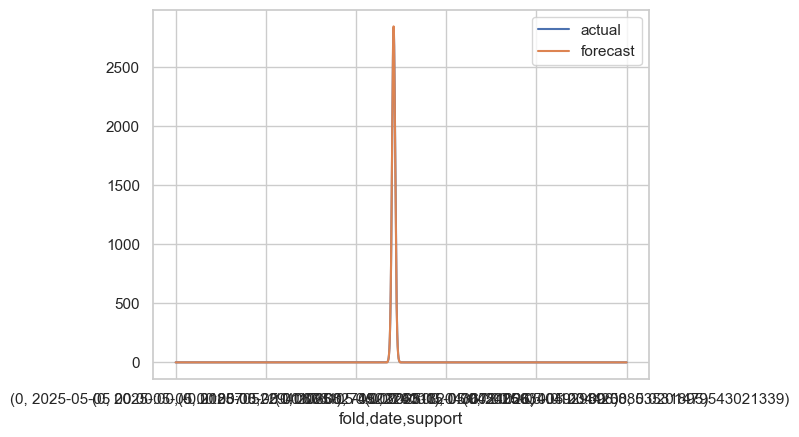

In [54]:
subset = df_mdfpc_records.iloc[0,:]["curves"].reset_index()
subset[subset["fold"]==0].set_index(["fold", "date", "support"]).plot()

TypeError: unhashable type: 'slice'

In [29]:
df_all_cvs.groupby(["name",], as_index=False)[accuracy_measures].mean().sort_values(by="KLD")

,name,KLD,JSD,L_1,L_2,L_INFTY
553,t-student_adaptive_df=3___rolling_w63___5___2,0.012927,0.000770,5742.164638,661.474103,116.725898
545,t-student_adaptive_df=3___rolling_w63___3___2,0.012970,0.000768,5760.589511,661.129673,116.813087
549,t-student_adaptive_df=3___rolling_w63___4___2,0.013008,0.000764,5723.657571,657.716388,115.745669
547,t-student_adaptive_df=3___rolling_w63___3___4,0.013026,0.000746,5610.189412,645.905060,114.215388
653,t-student_adaptive_df=4___rolling_w63___5___2,0.013037,0.000780,5767.087546,667.579878,117.410094
...,...,...,...,...,...,...
413,gaussian_rot_robust___False___5___2,2.630011,0.142779,42801.439851,5855.593021,3240.029755
417,gaussian_rot_robust___False___6___2,2.639644,0.154738,44582.626819,6054.790525,3252.801163
415,gaussian_rot_robust___False___5___4,2.678066,0.198657,50800.281655,7345.150829,4018.263138
419,gaussian_rot_robust___False___6___4,2.688972,0.207236,53019.874572,7609.324012,4090.601149


In [27]:
df_all_cvs[(df_all_cvs.fpc == "mdfpc") & (df_all_cvs.name.str.contains("w5"))].groupby(["name", "fpc"], as_index=False)[accuracy_measures].mean().sort_values(by="KLD")

,name,fpc,KLD,JSD,L_1,L_2,L_INFTY
33,epanechnikov_rot___rolling_w5___5___2,mdfpc,0.034880,0.002115,9440.849447,716.013227,92.294393
21,epanechnikov_rot___rolling_w5___2___2,mdfpc,0.035023,0.002087,9282.001935,702.848252,89.850771
29,epanechnikov_rot___rolling_w5___4___2,mdfpc,0.035077,0.002099,9355.536613,707.765406,90.697293
37,epanechnikov_rot___rolling_w5___6___2,mdfpc,0.035137,0.002141,9526.036719,722.467767,93.016679
25,epanechnikov_rot___rolling_w5___3___2,mdfpc,0.035146,0.002094,9317.560054,704.946302,90.184624
...,...,...,...,...,...,...,...
137,gaussian_rot_robust___rolling_w5___6___2,mdfpc,1.212169,0.269046,46239.517398,9791.318892,6051.334860
139,gaussian_rot_robust___rolling_w5___6___4,mdfpc,1.305367,0.250010,44669.963954,9285.743550,5652.731147
129,gaussian_rot_robust___rolling_w5___4___2,mdfpc,1.372860,0.234869,42410.305587,8575.328669,5075.781671
135,gaussian_rot_robust___rolling_w5___5___4,mdfpc,1.464839,0.261725,46436.924690,9416.142895,5553.620940


In [34]:
df_all_cvs[df_all_cvs.name == "t-student_adaptive_df=3___rolling_w63___5___2"]

,name,fpc,method,kde_params,postprocessing_method,dFPC_dimensions,VAR_q,fold,KLD,JSD,L_1,L_2,L_INFTY,kde_kernel,kde_fc_params,kde_pp_params
0,t-student_adaptive_df=3___rolling_w63___5___2,mdfpc,KLE,t-student_adaptive_df=3,rolling_w63,5,2,1,0.009398,0.000193,3933.521204,464.285155,77.813811,t-student,t-student_adaptive_df=3rolling_w63,t-student_adaptive_df=3rolling_w63
1,t-student_adaptive_df=3___rolling_w63___5___2,mdfpc,KLE,t-student_adaptive_df=3,rolling_w63,5,2,2,0.028522,0.001810,11034.577496,1209.205601,188.878901,t-student,t-student_adaptive_df=3rolling_w63,t-student_adaptive_df=3rolling_w63
2,t-student_adaptive_df=3___rolling_w63___5___2,mdfpc,KLE,t-student_adaptive_df=3,rolling_w63,5,2,3,0.008484,0.000286,3748.612060,412.769610,83.502141,t-student,t-student_adaptive_df=3rolling_w63,t-student_adaptive_df=3rolling_w63
3,t-student_adaptive_df=3___rolling_w63___5___2,mdfpc,KLE,t-student_adaptive_df=3,rolling_w63,5,2,4,0.009534,0.000099,2219.417999,249.708186,46.534973,t-student,t-student_adaptive_df=3rolling_w63,t-student_adaptive_df=3rolling_w63
4,t-student_adaptive_df=3___rolling_w63___5___2,mdfpc,KLE,t-student_adaptive_df=3,rolling_w63,5,2,5,0.054564,0.004229,15617.739054,1834.497548,382.359266,t-student,t-student_adaptive_df=3rolling_w63,t-student_adaptive_df=3rolling_w63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,t-student_adaptive_df=3___rolling_w63___5___2,dfpc,KLE,t-student_adaptive_df=3,rolling_w63,5,2,77,0.038286,0.003143,14013.394621,1618.122916,269.119787,t-student,t-student_adaptive_df=3rolling_w63,t-student_adaptive_df=3rolling_w63
158,t-student_adaptive_df=3___rolling_w63___5___2,dfpc,KLE,t-student_adaptive_df=3,rolling_w63,5,2,78,0.002608,0.000158,2516.749062,279.376467,55.257967,t-student,t-student_adaptive_df=3rolling_w63,t-student_adaptive_df=3rolling_w63
159,t-student_adaptive_df=3___rolling_w63___5___2,dfpc,KLE,t-student_adaptive_df=3,rolling_w63,5,2,79,0.019158,0.001492,9197.386433,1080.501223,218.376835,t-student,t-student_adaptive_df=3rolling_w63,t-student_adaptive_df=3rolling_w63
160,t-student_adaptive_df=3___rolling_w63___5___2,dfpc,KLE,t-student_adaptive_df=3,rolling_w63,5,2,80,0.029126,0.002330,10568.946184,1310.727768,245.823846,t-student,t-student_adaptive_df=3rolling_w63,t-student_adaptive_df=3rolling_w63


In [31]:
df_all_cvs["kde_kernel"] = df_all_cvs.kde_params.str.split("_", expand=True).iloc[:,0]
df_all_cvs["kde_pp_params"] = df_all_cvs.kde_params + df_all_cvs.postprocessing_method

In [32]:
df_all_cvs.groupby("kde_pp_params")[accuracy_measures].mean().sort_values(by="KLD")

,KLD,JSD,L_1,L_2,L_INFTY
kde_pp_params,,,,,
t-student_adaptive_df=3rolling_w63,0.013966,0.000801,5844.072448,672.501478,119.314749
t-student_adaptive_df=4rolling_w63,0.014225,0.000817,5878.762604,679.641366,120.380605
t-student_adaptive_df=5rolling_w63,0.014618,0.000844,5940.931218,688.617309,121.795489
t-student_cross_validate_df=5_loorolling_w63,0.015359,0.000869,5669.053040,626.294172,108.794808
t-student_cross_validate_df=4_loorolling_w63,0.017021,0.000987,6121.925807,684.363655,120.523855
t-student_cross_validate_df=3_loorolling_w63,0.020370,0.001240,6882.233170,787.095720,143.652028
t-student_cross_validate_df=5_loorolling_w21,0.021768,0.001468,7699.055517,722.008492,110.885050
t-student_adaptive_df=3rolling_w21,0.022026,0.001462,7950.294501,775.533812,122.594083
t-student_adaptive_df=4rolling_w21,0.022473,0.001495,8021.354679,786.600612,124.301587


In [23]:
df_all_cvs.groupby(["name", "fpc"], as_index=False)[accuracy_measures].mean().sort_values(by="KLD")

,name,fpc,KLD,JSD,L_1,L_2,L_INFTY
1294,t-student_adaptive_df=4___rolling_w63___3___4,dfpc,0.010267,0.000752,5478.232611,634.859036,113.113432
1494,t-student_adaptive_df=5___rolling_w63___3___4,dfpc,0.010294,0.000754,5490.740493,637.875272,113.761648
1106,t-student_adaptive_df=3___rolling_w63___5___2,dfpc,0.010300,0.000800,5676.881929,653.536567,114.883938
1094,t-student_adaptive_df=3___rolling_w63___3___4,dfpc,0.010352,0.000751,5475.567311,632.262765,112.580375
1306,t-student_adaptive_df=4___rolling_w63___5___2,dfpc,0.010399,0.000810,5683.939177,657.583412,115.690623
...,...,...,...,...,...,...,...
827,gaussian_rot_robust___False___5___2,mdfpc,4.865046,0.273337,59547.465097,10440.108397,6346.885391
835,gaussian_rot_robust___False___6___2,mdfpc,4.870569,0.296778,62675.077792,10815.963353,6369.714011
831,gaussian_rot_robust___False___5___4,mdfpc,5.052823,0.384641,74613.466303,13377.376670,7899.179639
839,gaussian_rot_robust___False___6___4,mdfpc,5.076645,0.400766,78077.962695,13855.327627,8037.716301


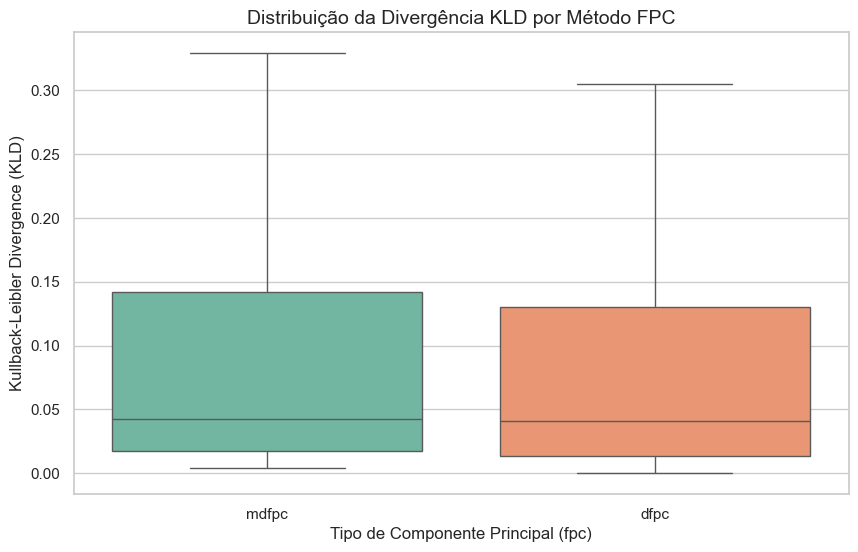

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

df_fpc = df_all_cvs[["fpc", "KLD"]]
df_fpc.reset_index(inplace=True)

# Configuração visual
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Criação do boxplot
# df_all_cvs é o dataframe da sua imagem
ax = sns.boxplot(x="fpc", y="KLD", data=df_fpc, palette="Set2", showfliers=False)

# Adicionando títulos e labels
plt.title("Distribuição da Divergência KLD por Método FPC", fontsize=14)
plt.xlabel("Tipo de Componente Principal (fpc)", fontsize=12)
plt.ylabel("Kullback-Leibler Divergence (KLD)", fontsize=12)

# Opcional: Escala logarítmica se houver outliers extremos (comum em KLD)
# plt.yscale('log')

plt.show()

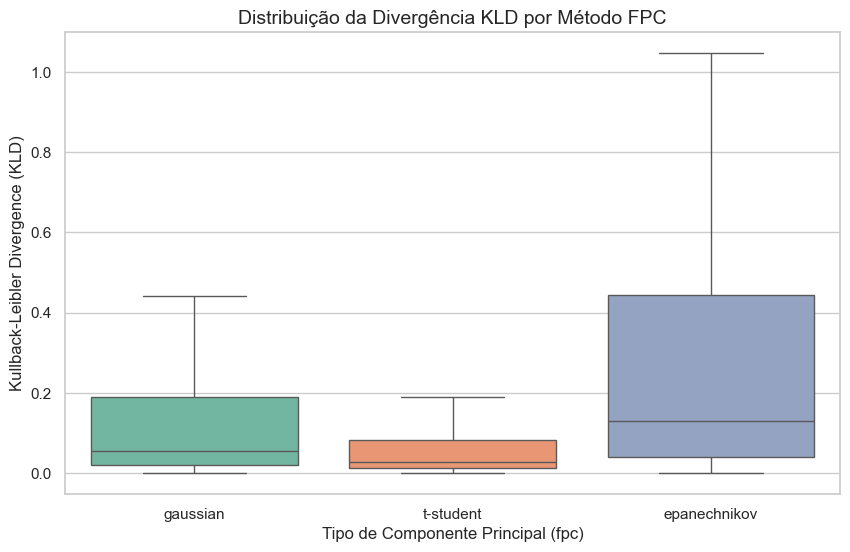

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

df_fpc = df_all_cvs[["kde_kernel", "KLD"]]
df_fpc.reset_index(inplace=True)

# Configuração visual
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Criação do boxplot
# df_all_cvs é o dataframe da sua imagem
ax = sns.boxplot(x="kde_kernel", y="KLD", data=df_fpc, palette="Set2", showfliers=False)

# Adicionando títulos e labels
plt.title("Distribuição da Divergência KLD por Método FPC", fontsize=14)
plt.xlabel("Tipo de Componente Principal (fpc)", fontsize=12)
plt.ylabel("Kullback-Leibler Divergence (KLD)", fontsize=12)

# Opcional: Escala logarítmica se houver outliers extremos (comum em KLD)
# plt.yscale('log')

plt.show()